In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


df = pd.read_parquet('../../dataset/data.parquet', engine='fastparquet')
df = df[df['Desired_Savings'] > 0].copy()


df['perc_nao_essenciais'] = (df['Eating_Out'] + df['Entertainment']) / df['Income']
df['perc_emprestimo'] = df['Loan_Repayment'] / df['Income']
df['Vulnerable'] = ((df['perc_emprestimo'] > 0.10).astype(int) + 
                    (df['perc_nao_essenciais'] > 0.085).astype(int) + 
                    ((df['Disposable_Income'] - df['Desired_Savings']) / df['Income'] < 0.10).astype(int) + 
                    (df['Potential_Savings_Groceries'] / df['Income'] > 0.08).astype(int) >= 2).astype(int)


df['Rent_Ratio'] = df['Rent'] / df['Income']
df['Healthcare_Ratio'] = df['Healthcare'] / df['Income']
df['Education_Ratio'] = df['Education'] / df['Income']
df['Groceries_Ratio'] = df['Groceries'] / df['Income']
df['Transport_Ratio'] = df['Transport'] / df['Income']
df['Utilities_Ratio'] = df['Utilities'] / df['Income']
df['Insurance_Ratio'] = df['Insurance'] / df['Income']


df['Total_Fixed_Ratio'] = (df['Rent_Ratio'] + df['Healthcare_Ratio'] + 
                           df['Education_Ratio'] + df['Groceries_Ratio'] + 
                           df['Transport_Ratio'] + df['Utilities_Ratio'] + 
                           df['Insurance_Ratio'])


df['Remaining_Ratio'] = 1.0 - df['Total_Fixed_Ratio']


df['Fixed_Cost_Per_Dependent'] = df['Total_Fixed_Ratio'] / (df['Dependents'] + 1)


features_percentuais = [
    'Age', 
    'Dependents', 
    'Rent_Ratio', 
    'Healthcare_Ratio', 
    'Education_Ratio', 
    'Groceries_Ratio',
    'Transport_Ratio',
    'Utilities_Ratio',
    'Insurance_Ratio',
    'Total_Fixed_Ratio',        # Nova Feature
    'Remaining_Ratio',          # Nova Feature
    'Fixed_Cost_Per_Dependent'  # Nova Feature
]

X = df[features_percentuais]
y = df['Vulnerable']

# 6. Divisão de Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

--- Distribuição Absoluta ---
Vulnerable
0    15790
1     4098
Name: count, dtype: int64

--- Distribuição Percentual (%) ---
Vulnerable
0    79.39
1    20.61
Name: proportion, dtype: float64


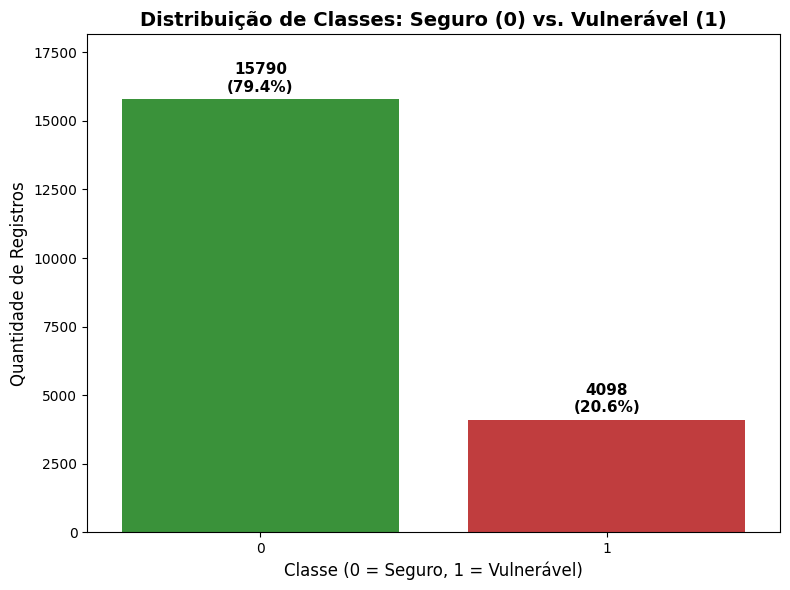

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


contagem = df['Vulnerable'].value_counts()
percentual = df['Vulnerable'].value_counts(normalize=True) * 100

print("--- Distribuição Absoluta ---")
print(contagem)
print("\n--- Distribuição Percentual (%) ---")
print(percentual.round(2))


plt.figure(figsize=(8, 6))


ax = sns.countplot(
    x='Vulnerable', 
    data=df, 
    palette=['#2ca02c', '#d62728'], # Verde para Seguro(0), Vermelho para Vulnerável(1)
    hue='Vulnerable',
    legend=False
)


total = len(df)
for p in ax.patches:
    altura = p.get_height()
    # Verifica se a altura é maior que 0 para evitar erros em barras vazias
    if altura > 0:
        porcentagem = f'{(altura/total)*100:.1f}%'
        texto_anotacao = f'{int(altura)}\n({porcentagem})'
        ax.annotate(
            texto_anotacao, 
            (p.get_x() + p.get_width() / 2., altura),
            ha='center', 
            va='center', 
            xytext=(0, 15), 
            textcoords='offset points',
            fontsize=11, 
            fontweight='bold'
        )


plt.title('Distribuição de Classes: Seguro (0) vs. Vulnerável (1)', fontsize=14, fontweight='bold')
plt.xlabel('Classe (0 = Seguro, 1 = Vulnerável)', fontsize=12)
plt.ylabel('Quantidade de Registros', fontsize=12)


plt.ylim(0, df['Vulnerable'].value_counts().max() * 1.15)

plt.tight_layout()
plt.show()

--- Configuração do Modelo ---
Scale Pos Weight Aplicado: 3.85

Treinando o modelo XGBoost...


c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:36:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.85      0.60      0.71      3158
           1       0.28      0.60      0.39       820

    accuracy                           0.60      3978
   macro avg       0.57      0.60      0.55      3978
weighted avg       0.74      0.60      0.64      3978



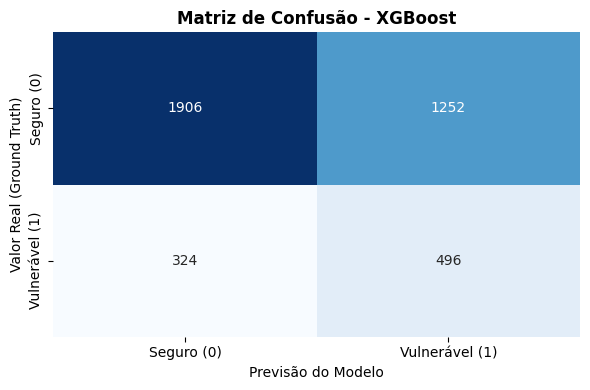

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


num_neg = 15790
num_pos = 4098
peso_balanceamento = num_neg / num_pos

print(f"--- Configuração do Modelo ---")
print(f"Scale Pos Weight Aplicado: {peso_balanceamento:.2f}\n")


modelo_xgb = xgb.XGBClassifier(
    scale_pos_weight=peso_balanceamento,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,        
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)


print("Treinando o modelo XGBoost...")
modelo_xgb.fit(X_train, y_train)


y_pred = modelo_xgb.predict(X_test)


print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
matriz = confusion_matrix(y_test, y_pred)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Seguro (0)', 'Vulnerável (1)'], 
            yticklabels=['Seguro (0)', 'Vulnerável (1)'])
plt.title('Matriz de Confusão - XGBoost', fontweight='bold', fontsize=12)
plt.ylabel('Valor Real (Ground Truth)')
plt.xlabel('Previsão do Modelo')
plt.tight_layout()
plt.show()